# 📌 Step1 导入数据集和依赖库

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置pandas显示优化
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 2000)
pd.set_option('display.max_colwidth',35)

# 设置显示中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv("4.creditcard.csv")

print(df.head())
print(f"\n数据形状：{df.shape}")
print(f"\n数据类型与缺失值情况：")
print(df.info())

   Time        V1        V2        V3        V4        V5        V6        V7        V8        V9       V10       V11       V12       V13       V14       V15       V16       V17       V18       V19       V20       V21       V22       V23       V24       V25       V26       V27       V28  Amount  Class
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169  1.468177 -0.470401  0.207971  0.025791  0.403993  0.251412 -0.018307  0.277838 -0.110474  0.066928  0.128539 -0.189115  0.133558 -0.021053  149.62      0
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772  0.635558  0.463917 -0.114805 -0.183361 -0.145783 -0.069083 -0.225775 -0.638672  0.101288 -0.339846  0.167170  0.125895 -0.008983  0.014724    2.69      0
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461  0.247676 -1.

### 先梳理当前已知信息：

数据集 `creditcard.csv`

- 样本总数：284807 条，31 列
- 无缺失值（所有字段 Non-Null Count 全部填满）
- 字段说明：
  - `Time`：交易距离首次交易的秒数
  - `V1~V28`：经过 PCA 降维后的脱敏特征（原始交易信息出于隐私保护不公开）
  - `Amount`：交易金额
  - `Class`：**标签，0 = 正常交易，1 = 欺诈交易**

### 🤔 思考题

前面泰坦尼克、鸢尾花数据集类别分布基本均衡；信用卡欺诈场景：绝大多数交易正常，欺诈样本极少。

**问题 1：如果直接统计准确率，会存在什么巨大陷阱？**

我们第一步先查看标签分布，验证类别不平衡程度。

In [4]:
# 统计标签分布
label_cnt = df["Class"].value_counts()
print("类别分布：")
print(label_cnt)
print(f"正常交易(0)占比：{label_cnt[0] / len(df) * 100:.2f}%")
print(f"欺诈交易(1)占比：{label_cnt[1] / len(df) * 100:.2f}%")

类别分布：
Class
0    284315
1       492
Name: count, dtype: int64
正常交易(0)占比：99.83%
欺诈交易(1)占比：0.17%


### 结果分析：

欺诈样本只占 0.17%，若模型无脑全部预测为 0，**准确率依旧高达 99.83%**，但是完全识别不出欺诈！**准确率在不平衡数据集彻底失效，不能作为主评价指标！**

此外，划分数据集**必须使用 `stratify=y`**，保证训练集、测试集中欺诈样本占比和原始数据一致。如果不使用分层抽样，很有可能测试集里几乎没有欺诈样本，评估完全失真。

### 🤔 思考题

常规指标准确率失效。欺诈检测业务里：

- **真正例 TP**：欺诈交易，成功识别
- **假负例 FN**：欺诈交易，被判定为正常（漏检，损失资金，业务最不能接受）
- **假正例 FP**：正常交易，误判为欺诈（误报警，打扰用户）

问题：我们更应该关注召回率 (Recall) 还是精确率 (Precision)？除此之外，不平衡数据集公认的核心评价指标是什么？

# 📌 Step2 数据集划分 + 特征预处理

先说明两个特征处理要点：

1. `Time` 时间特征业务意义弱，一般直接删除；
2. `Amount` 交易金额数值范围大，需要标准化；V1~V28 已经是 PCA 标准化后的特征，不用重复处理。

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1.构造特征与标签
X = df.drop(["Time", "Class"], axis=1)
y = df["Class"]

# 2.分层划分训练集、测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"训练集大小：{X_train.shape}")
print(f"测试集大小：{X_test.shape}")
print(f"\n训练集标签分布：{y_train.value_counts()}")
print(f"\n测试集标签分布：{y_test.value_counts()}")

# 3.标准化 Amount
scaler = StandardScaler()
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

训练集大小：(227845, 29)
测试集大小：(56962, 29)

训练集标签分布：Class
0    227451
1       394
Name: count, dtype: int64

测试集标签分布：Class
0    56864
1       98
Name: count, dtype: int64


### 🤔 引导思考题

现在我们直接在原始不平衡数据集训练逻辑回归。

猜想一下模型行为：样本极度不均衡，模型为了降低总体损失，会偏向预测类别 0（正常交易）。

1. 测试集准确率看起来很高，但是欺诈样本大量漏检；
2. 此时**准确率完全不能用来衡量模型好坏**。

那我们用什么指标作为核心评判标准？

> 答：AUC、召回率 Recall、精确率 Precision、F1、PR 曲线。

# 📌 Step3 训练基础模型：逻辑回归（原始不平衡数据，不做采样）

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

# 训练
lr = LogisticRegression(max_iter=300, random_state=42)
lr.fit(X_train, y_train)

# 预测
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:,1] # 获取类别1(欺诈)概率

# 指标计算
acc = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("===== 逻辑回归（原始不平衡数据集）=====")
print(f"准确率 Accuracy: {acc * 100:.2f}%")
print(f"召回率 Recall(欺诈检出率): {recall * 100:.2f}%")
print(f"精确率 Precision: {precision * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"AUC: {auc * 100:.2f}%")

print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred))
print("\n分类报告：")
print(classification_report(y_test, y_pred))

===== 逻辑回归（原始不平衡数据集）=====
准确率 Accuracy: 99.92%
召回率 Recall(欺诈检出率): 64.29%
精确率 Precision: 82.89%
F1-score: 72.41%
AUC: 95.52%

混淆矩阵：
[[56851    13]
 [   35    63]]

分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



### 结果分析

混淆矩阵
```txt
[[56851    13]   # 正常交易：56851正确，13条误报
 [   35    63]]  # 欺诈交易：35条漏检，63条成功检出
```

测试集一共 98 条欺诈：成功抓到 63 条，漏掉 35 条 → 召回率 64.29%，准确率高达 99.92%，极具迷惑性，再次印证：

> **极度不平衡数据集，准确率毫无参考价值！**

### 🤔 引导思考题

想要改善漏检问题，第一种轻量化方案：逻辑回归设置 `class_weight='balanced'`，模型损失函数里，自动给少数类（欺诈 1）施加更大惩罚权重。

思考：加上这个参数后，预期召回率会上升还是下降？精确率大概率如何变化？

In [7]:
lr_balanced = LogisticRegression(max_iter=300, random_state=42, class_weight="balanced")
lr_balanced.fit(X_train, y_train)

y_pred_balanced = lr_balanced.predict(X_test)
y_pred_proba_balanced = lr_balanced.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_balanced)
recall = recall_score(y_test, y_pred_balanced)
precision = precision_score(y_test, y_pred_balanced)
f1 = f1_score(y_test, y_pred_balanced)
auc = roc_auc_score(y_test, y_pred_proba_balanced)

print("===== 逻辑回归 class_weight='balanced' =====")
print(f"准确率 Accuracy: {acc * 100:.2f}%")
print(f"召回率 Recall(欺诈检出率): {recall * 100:.2f}%")
print(f"精确率 Precision: {precision * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"AUC: {auc * 100:.2f}%")

print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred_balanced))
print("\n分类报告：")
print(classification_report(y_test, y_pred_balanced))

===== 逻辑回归 class_weight='balanced' =====
准确率 Accuracy: 97.46%
召回率 Recall(欺诈检出率): 91.84%
精确率 Precision: 5.89%
F1-score: 11.06%
AUC: 97.14%

混淆矩阵：
[[55425  1439]
 [    8    90]]

分类报告：
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



### 结果分析

混淆矩阵
```txt
[[55425  1439]   # 正常交易：1439笔被误判为欺诈（大量误报警）
 [    8    90]]  # 欺诈交易：仅漏掉8笔，90笔成功识别
```

对比不加权重的模型：

- ✅ **召回率 64.29% → 91.84%**：漏检大幅减少，符合金融风控诉求
- ❌ **精确率 82.89% → 5.89%**：代价极其明显，误报爆炸式增长

简单理解权衡关系：`class_weight="balanced"` 强制模型优先识别少数类，模型为了尽量不漏掉欺诈，宁可错杀大量正常交易。

业务场景思考：如果银行短信频繁误提醒用户 “您这笔交易疑似欺诈”，用户投诉量会暴增，无法直接上线。

> 核心知识点：**精确率与召回率天然存在权衡（Trade-off）**

### 🤔 引导思考题

我们目前使用 `predict()`，默认阈值 = 0.5。对于不平衡数据集，0.5 这个阈值往往不是最优选择。

思路：不改动模型，只调整判定阈值。比如把阈值从 0.5 下调到 0.2，或者上调到 0.8，会发生什么？

- 阈值降低 → 更容易判定为欺诈 → 召回上升、精确率下降
- 阈值抬高 → 更谨慎判定欺诈 → 召回下降、精确率上升

### 阈值可调，画出 ROC 曲线 & PR 曲线

ROC 曲线容易对不平衡数据产生乐观假象；**PR 曲线（精确率 - 召回率曲线）更适合不平衡二分类**。

1. ROC 曲线：横轴 FPR（正常样本被误判的比例）；样本极度不均衡时，FPR 看上去很低，容易误导。
2. PR 曲线：只聚焦正样本（欺诈），**工业界不平衡分类首选评估曲线**。

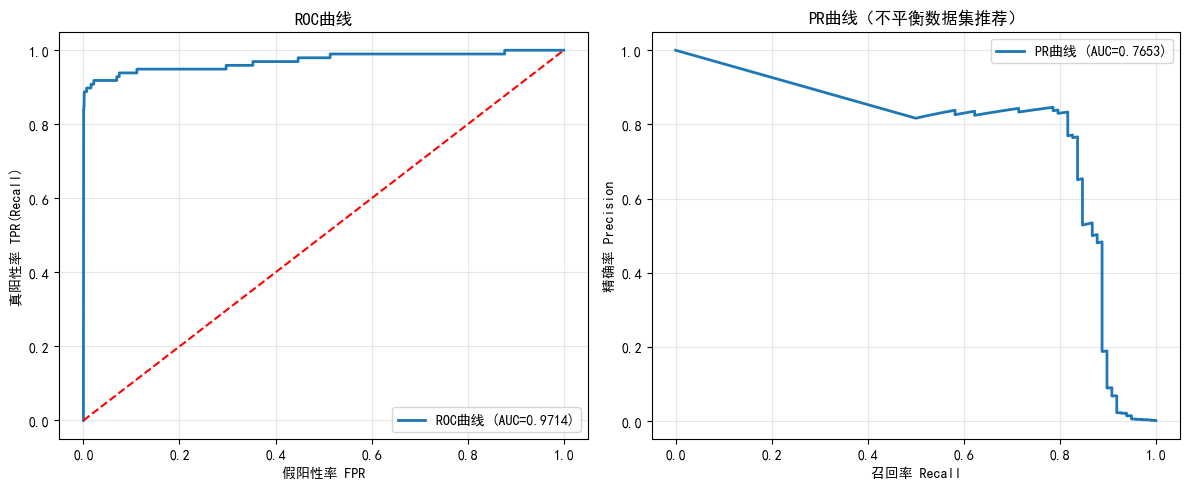

PR曲线下面积 PR-AUC： 0.7653147444807694


In [8]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

# ---------- ROC曲线 ----------
fpr, tpr, thresholds_roc = roc_curve(y_test, y_pred_proba_balanced)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, lw=2, label=f'ROC曲线 (AUC={roc_auc:.4f})')
plt.plot([0,1],[0,1],'r--')
plt.xlabel("假阳性率 FPR")
plt.ylabel("真阳性率 TPR(Recall)")
plt.title("ROC曲线")
plt.legend()
plt.grid(alpha=0.3)

# ---------- PR曲线 ----------
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_balanced)
pr_auc = auc(recall, precision)

plt.subplot(1,2,2)
plt.plot(recall, precision, lw=2, label=f'PR曲线 (AUC={pr_auc:.4f})')
plt.xlabel("召回率 Recall")
plt.ylabel("精确率 Precision")
plt.title("PR曲线（不平衡数据集推荐）")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 寻找折中阈值示例
print("PR曲线下面积 PR-AUC：", pr_auc)

### 🤔 下一条技术路线思考

除了加权损失、调整阈值，还有一大类方法：**重采样**

两类方案：

1. 欠采样：随机删掉大量正常交易 → 缺点：丢失大量有效信息
2. 过采样：
   - 简单复制欺诈样本：极易过拟合
   - SMOTE：插值合成全新欺诈样本（主流方案）

### 思考题

SMOTE 能不能作用在测试集？为什么？

# 📌 Step4 SMOTE 过采样实验

思路：在训练集人工插值生成更多欺诈样本，让训练集类别接近平衡；测试集维持原样不变。

In [ ]:
from imblearn.over_sampling import SMOTE

# 初始化SMOTE
smote = SMOTE(random_state=42) # 寻找少数类（欺诈）近邻样本，线性插值创造新的合成欺诈样本，不是简单复制，缓解过拟合。

# 仅重采样训练集！
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("==== SMOTE采样后训练集分布 ====")
print(y_train_smote.value_counts())

# 使用采样后的数据集训练逻辑回归
lr_smote = LogisticRegression(max_iter=300, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_smote)
recall = recall_score(y_test, y_pred_smote)
precision = precision_score(y_test, y_pred_smote)
f1 = f1_score(y_test, y_pred_smote)
auc = roc_auc_score(y_test, y_pred_proba_smote)

print("\n===== 逻辑回归 + SMOTE过采样 =====")
print(f"准确率 Accuracy: {acc * 100:.2f}%")
print(f"召回率 Recall(欺诈检出率): {recall * 100:.2f}%")
print(f"精确率 Precision: {precision * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"AUC: {auc * 100:.2f}%")

print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred_smote))
print("\n分类报告：")
print(classification_report(y_test, y_pred_smote))

==== SMOTE采样后训练集分布 ====
Class
0    227451
1    227451
Name: count, dtype: int64

===== 逻辑回归 + SMOTE过采样 =====
准确率 Accuracy: 97.31%
召回率 Recall(欺诈检出率): 91.84%
精确率 Precision: 5.58%
F1-score: 10.53%
AUC: 97.00%

混淆矩阵：
[[55342  1522]
 [    8    90]]

分类报告：
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



### 结果分析与对比

先汇总三组逻辑回归关键指标方便直观对比

|方案|	Recall|	Precision|	F1|	AUC|
|:--|:--:|:--:|:--|:--:|
|原始不平衡 LR|	64.29%|	82.89%|	72.41%|	95.52%|
|LR + class_weight="balanced"|	91.84%|	5.89%|	11.06%|	97.14%|
|LR + SMOTE 过采样|	91.84%|	5.58%|	10.53%|	97.00%|

现象解读：SMOTE 之后训练集正负样本 1:1 平衡，最终效果和`class_weight="balanced"`高度接近；召回同样拉高到 91.84%，只漏掉 8 条欺诈；但精确率依旧极低，产生大量误报（1522 条正常交易被判定欺诈）。

> 原因：逻辑回归本身是线性模型，决策边界表达能力有限，单纯平衡样本分布，很难同时兼顾精确率与召回率。

线性模型遇到瓶颈，我们更换非线性模型：随机森林。
思考两点：

1. 随机森林同样支持`class_weight="balanced"`，要不要使用？
2. 树模型捕捉非线性特征组合，相比逻辑回归，有没有希望改善精确率过低的问题？

# 📌 Step5 使用随机森林

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced", # 给欺诈样本更大损失权重
    random_state=42,
    n_jobs=-1 # 调用全部 CPU 核心加速训练（数据集很大，提速明显）
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:,1]

acc = accuracy_score(y_test, y_pred_rf)
recall = recall_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf)
f1 = f1_score(y_test, y_pred_rf)
auc = roc_auc_score(y_test, y_pred_proba_rf)

print("===== 随机森林 class_weight='balanced' =====")
print(f"准确率 Accuracy: {acc * 100:.2f}%")
print(f"召回率 Recall(欺诈检出率): {recall * 100:.2f}%")
print(f"精确率 Precision: {precision * 100:.2f}%")
print(f"F1-score: {f1 * 100:.2f}%")
print(f"AUC: {auc * 100:.2f}%")

print("\n混淆矩阵：")
print(confusion_matrix(y_test, y_pred_rf))
print("\n分类报告：")
print(classification_report(y_test, y_pred_rf))

===== 随机森林 class_weight='balanced' =====
准确率 Accuracy: 99.96%
召回率 Recall(欺诈检出率): 81.63%
精确率 Precision: 91.95%
F1-score: 86.49%
AUC: 96.73%

混淆矩阵：
[[56857     7]
 [   18    80]]

分类报告：
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.82      0.86        98

    accuracy                           1.00     56962
   macro avg       0.96      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



### 结果对比与分析

|方案|	Recall|	Precision|	F1|	AUC|
|:--|:--:|:--:|:--|:--:|
|原始不平衡 LR|	64.29%|	82.89%|	72.41%|	95.52%|
|LR + class_weight="balanced"|	91.84%|	5.89%|	11.06%|	97.14%|
|LR + SMOTE 过采样|	91.84%|	5.58%|	10.53%|	97.00%|
|随机森林 + class_weight="balanced"  |81.63%| 91.95%| 86.49%| 96.73%|

混淆矩阵
```txt
[[56857     7]   # 正常交易仅7笔误判欺诈（误报极少）
 [   18    80]]  # 98条欺诈，80条检出，18条漏检
```

#### 关键结论

1. 随机森林大幅优于线性逻辑回归：
   - 逻辑回归开启平衡权重后直接陷入「高召回、极低精确率」，大量误报警无法商用；
   - 非线性随机森林可以学习特征交互，很好平衡精确率与召回，F1 达到 86.49%，是目前最优模型。
2. 权衡关系清晰体现：
   - 相比于带权重 LR：召回略微下降，但精确率从 5% 暴涨至 91.95%；
   - 业务价值：既抓住绝大多数欺诈，又几乎不会骚扰正常用户。

### 🤔 引导思考题

当前依旧使用默认阈值 `0.5` 划分正负样本。而我们手上有模型输出的欺诈概率 `y_pred_proba_rf`。能不能通过调整阈值，进一步微调？

- 想要更少漏检 → 降低阈值
- 想要更少误报 → 抬高阈值

我们写一段代码遍历阈值，寻找业务最优平衡点。

# 📌 Step6 寻找最优平衡点

In [ ]:
# 取出随机森林输出的欺诈概率（数组）
proba_1 = y_pred_proba_rf
y_true = y_test.values # y_test 是 Series，.value 将其转为 numpy 一维数组

# 遍历一系列阈值
threshold_list = np.linspace(0.05, 0.95, 30) # 生成 0.05~0.95 之间一系列候选阈值
best_f1, best_thresh = 0.0, 0.0

print("阈值\t召回率\t精确率\tF1")
for thresh in threshold_list:
    y_cut = (proba_1 >= thresh).astype(int) # y_cut: 自定义阈值下的预测标签数组
    recall = recall_score(y_true, y_cut)
    precision = precision_score(y_true, y_cut)
    f1 = f1_score(y_true, y_cut)
    print(f"{thresh:.2f}\t{recall*100:.2f}\t{precision*100:.2f}\t{f1*100:.2f}")
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

print(f"\nF1最优阈值：{best_thresh:.2f}，最优F1={best_f1*100:.2f}%")

阈值	召回率	精确率	F1
0.05	89.80	36.82	52.23
0.08	89.80	57.14	69.84
0.11	89.80	65.67	75.86
0.14	89.80	70.97	79.28
0.17	88.78	75.00	81.31
0.21	88.78	75.65	81.69
0.24	86.73	75.89	80.95
0.27	84.69	77.57	80.98
0.30	84.69	79.81	82.18
0.33	84.69	83.00	83.84
0.36	83.67	85.42	84.54
0.39	83.67	86.32	84.97
0.42	83.67	90.11	86.77
0.45	82.65	90.00	86.17
0.48	81.63	91.95	86.49
0.52	81.63	93.02	86.96
0.55	78.57	92.77	85.08
0.58	77.55	93.83	84.92
0.61	77.55	95.00	85.39
0.64	77.55	95.00	85.39
0.67	77.55	96.20	85.88
0.70	75.51	96.10	84.57
0.73	73.47	96.00	83.24
0.76	73.47	96.00	83.24
0.79	72.45	95.95	82.56
0.83	70.41	97.18	81.66
0.86	67.35	97.06	79.52
0.89	62.24	96.83	75.78
0.92	53.06	96.30	68.42
0.95	47.96	97.92	64.38

F1最优阈值：0.52，最优F1=86.96%
